In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy, assemble_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
import matplotlib as mpl
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    #ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def Fichera(deg,N):
    kvs = 7*(3 * (bspline.make_knots(deg, 0.0, 1.0, N),),)
    
    #define geometry
    geos = [
        geometry.unit_cube(),
        geometry.unit_cube().translate(( 0,  0, -1)),
        geometry.unit_cube().translate(( 0, -1,  0)),
        geometry.unit_cube().translate((-1,  0,  0)),
        geometry.unit_cube().translate((-1, -1,  0)),
        geometry.unit_cube().translate((-1,  0, -1)),
        geometry.unit_cube().translate(( 0, -1, -1)),
        geometry.unit_cube().translate((-1, -1, -1))
    ]
    
    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch3D(patches)
    M.set_boundary_id({1:{(2,2),(6,2),(4,2),(4,4),(3,4),(5,4),(6,0),(1,0),(5,0),(6,4),(5,2),(4,0)}})
    return M

In [4]:
def has_origin(M):
    out={}
    for p in range(len(M.patches)):
        if np.any(np.all(np.isclose(topology.corners(M.geos[p]), np.array([0,0,0]), atol=1e-14), axis=-1)):
            out[p]=None
    return out

In [5]:
alpha=0.25
u_exact = lambda x,y,z: (x**2+y**2+z**2)**(alpha/2)
grad_u = lambda x, y, z: (
    alpha * x * (x**2 + y**2 + z**2)**((alpha - 2)/2),
    alpha * y * (x**2 + y**2 + z**2)**((alpha - 2)/2),
    alpha * z * (x**2 + y**2 + z**2)**((alpha - 2)/2),
)
f = lambda x,y,z: -alpha*(alpha+1)*(x**2+y**2+z**2)**((alpha-2)/2)

deg = 4
M = Fichera(deg,deg+1)
maxiter = 4 #p2: 15 #p3: 22 #p4: 25
maxpatches = 15000
uniform = True
R = np.zeros((maxiter, 7))
plot=True

for k in range(maxiter):
    print(k)
    if plot:
        M.plot_boundary()
        #plt.axis('off');
        plt.axis('scaled');
        plt.savefig('/mnt/c/Users/stefa/Pictures/Fichera/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
        plt.close();
    MB = assemble.MultiBasis(M, subspace='C0')
    
    B = (MB.B@MB.R_related.T).tocsr()
    t1 =time.time()
    Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
    R[k,5]= time.time()-t1
    Basis = scipy.sparse.hstack([MB.R_free.T, MB.R_related.T@Basis], format='csc')
    R[k,6]=time.time()-t1
    
    R[k,0] = MB.nDofs
    R[k,1] = MB.nPatches

    #Mh = MB.assemble_volume('u * v *dx', arity=2)
    Kh = MB.assemble_volume('inner(grad(u),grad(v))*dx', arity=2)
    Fh = MB.assemble_volume('f * v * dx', arity=1, f=f)

    dir_bcs = MB.set_fixed_boundary({0:u_exact,1:u_exact})
    LS = assemble.RestrictedLinearSystem(Kh,Fh,dir_bcs)
    uh_ = operators.make_solver(LS.A, spd=True)@LS.b
    uh_=LS.complete(uh_)
    uh = MB.function(uh_)

    Eerr = MB.H1err(u_exact,grad_u,uh)

    R[k,2] = Eerr

    if not uniform:
        err_ind=adaptive.mp_resPois(MB, uh_, nu=1, f={0:f})
        eta = np.linalg.norm(err_ind)
        R[k,3] = eta
        R[k,4] = eta/Eerr
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if MB.nPatches + 3*len(marked_patches) >= maxpatches:
            break;

    # if k<maxiter[i]-1:
    #     if not uniform:
    #         t = time.time()
    #         M.h_refine(h_ref=marked_patches);
    #         print('splitting took '+str(time.time()-t)+' seconds.')
    #     else:
    #         M.h_refine(h_ref=-1);
    print(MB.nPatches)
    #print(len(marked_patches))

    if k < maxiter-1:
        if uniform:
            M.h_refine(-1);
        else:
            print(len(marked_patches))
            t=time.time()
            M.h_refine(marked_patches);
            print('splitting took '+str(time.time()-t)+' seconds.')

    if uniform:
        np.save('Fichera_uniform_p'+str(deg),R)
    else:
        np.save('Fichera_adaptive_p'+str(deg),R)
    
    # eh=uh-u_exact
    # print(np.sqrt(eh@Kh@eh))

0
setting up constraints took 0.012510299682617188 seconds.
Basis setup took 0.0021181106567382812 seconds
7
1
setting up constraints took 0.013153076171875 seconds.
Basis setup took 0.0025680065155029297 seconds
7
2
setting up constraints took 0.014880657196044922 seconds.
Basis setup took 0.0055773258209228516 seconds
7
3
setting up constraints took 0.021740198135375977 seconds.
Basis setup took 0.02324199676513672 seconds
7


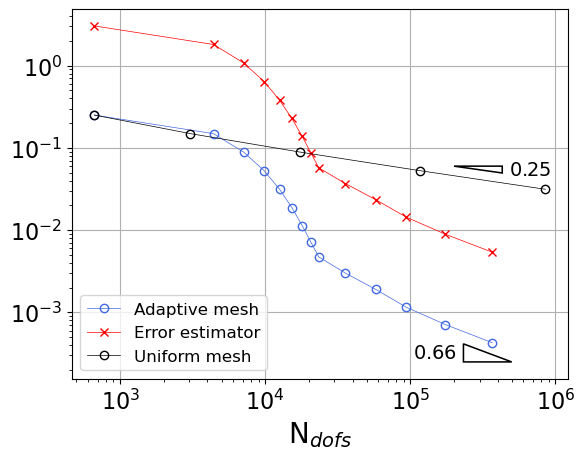

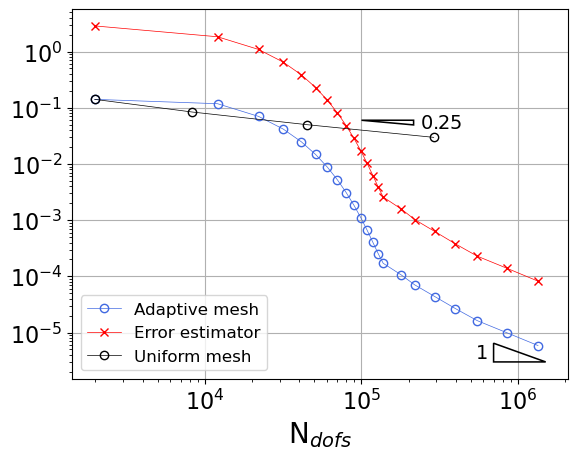

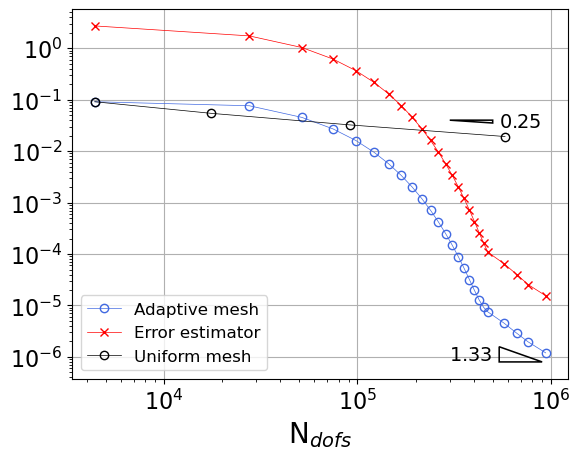

In [15]:
#R_a = np.load('Inductor_adaptive.npy')
#R_u = np.load('Inductor_uniform.npy')

# numdofs=R_u[:,0]
# # numdofs_a = R_a[:,0]
# Eerr = R_u[:,2]
# # Eerr_a = R_a[:,2]
pos=((5*1e5,2.5*1e-4),(1.5*1e6,3*1e-6),(9*1e5,8*1e-7))
pos_u=((2*1e5,6*1e-2),(1e5,6*1e-2),(3*1e5,4*1e-2))
w = (1.5,1.5,1.0)
inv = (True,True,True)
slope=(0.66,int(1),1.33)
for i, deg in enumerate((2,3,4)):
    R_a = np.load('Fichera_adaptive_p'+str(deg)+'.npy')
    R_u = np.load('Fichera_uniform_p'+str(deg)+'.npy')
    
    numdofs=R_u[:,0]
    numdofs_a = R_a[:,0]

    Eerr = R_u[:,2]
    Eerr_a = R_a[:,2]

    Eta = R_a[:,3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]

    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]

    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=slope[i],inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.25,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Fichera_p'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

In [9]:
deg=2
M = Fichera(deg,deg+1)
MB = assemble.MultiBasis(M, subspace='C0')

maxiter=7
R=np.zeros((maxiter,3))
for i in range(maxiter):
    M.h_refine(-1);
    MB = assemble.MultiBasis(M)

    t=time.time()
    B=MB.set_constraints(subspace='C0')
    R[i,0] = MB.nLocDofs
    R[i,1] = time.time()-t

    I = np.unique(B.indices)
    F = np.setdiff1d(np.arange(MB.N_ofs[-1]),I)

    R_related = scipy.sparse.coo_matrix((np.ones(len(I)),(np.arange(len(I)),I)),shape=(len(I),MB.N_ofs[-1]))
    R_free = scipy.sparse.coo_matrix((np.ones(len(F)),(np.arange(len(F)),F)),shape=(len(F),MB.N_ofs[-1]))
    
    B = (MB.B@R_related.T).tocsr()
    t1 =time.time()
    Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
    Basis = scipy.sparse.hstack([R_free.T, R_related.T@Basis], format='csc')
    R[i,2]=time.time()-t1
np.save('Fichera_runtime_uniform_p'+str(deg),R)

setting up constraints took 0.01116180419921875 seconds.
Basis setup took 0.0016613006591796875 seconds
setting up constraints took 0.011248588562011719 seconds.
setting up constraints took 0.013237476348876953 seconds.
setting up constraints took 0.015495777130126953 seconds.
setting up constraints took 0.02351975440979004 seconds.
setting up constraints took 0.05933237075805664 seconds.
setting up constraints took 0.18390583992004395 seconds.
setting up constraints took 0.8163793087005615 seconds.


In [10]:
R

array([[3.58400e+03, 1.13673e-02, 2.48807e-01],
       [1.92080e+04, 1.36039e-02, 7.77245e-04],
       [1.23032e+05, 1.56345e-02, 1.96815e-03],
       [8.75000e+05, 2.36940e-02, 1.24974e-02],
       [6.58834e+06, 5.98216e-02, 2.86691e-01],
       [5.11097e+07, 1.85650e-01, 2.01268e+00],
       [4.02587e+08, 8.21365e-01, 1.63147e+01]])

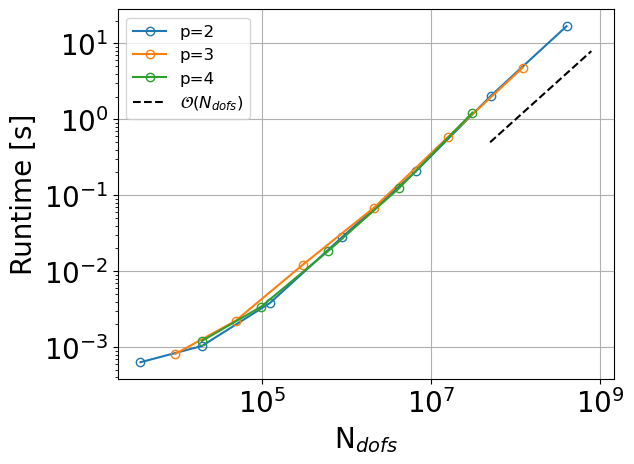

In [7]:
R2 = np.load('Fichera_runtime_uniform_p2.npy')
R3 = np.load('Fichera_runtime_uniform_p3.npy')
R4 = np.load('Fichera_runtime_uniform_p4.npy')

#R2[0,2]=

plt.loglog(R2[:,0], R2[:,2], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,2], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R4[:,0], R4[:,2], "o-", label="p=4",markerfacecolor='none')

# reference O(N) line
x = 5*1e7
y = 5*1e-1
l=1.2
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--", color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend(loc='upper left',prop={'size': 12})
plt.grid(True)
plt.savefig('runtime_uniform.pdf', bbox_inches='tight')

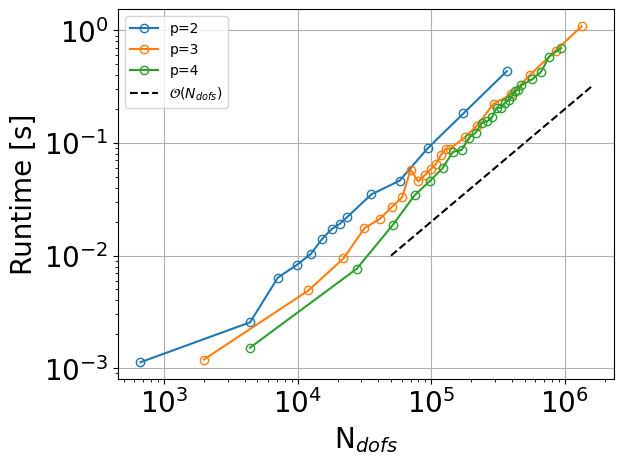

In [19]:
R2 = np.load('Fichera_adaptive_p2.npy')
R3 = np.load('Fichera_adaptive_p3.npy')
R4 = np.load('Fichera_adaptive_p4.npy')

#print(R3)

plt.loglog(R2[:,0], R2[:,6], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,6], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R4[:,0], R4[:,6], "o-", label="p=4",markerfacecolor='none')

# reference O(N) line
x = 5*1e4
y = 1e-2
l=1.5
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--",color='black', label=r"$\mathcal{O}(N_{dofs})$")

ax.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.savefig('Fichera_runtime_adaptive.pdf', bbox_inches='tight')

In [21]:
R3 = np.load('Fichera_adaptive_p3.npy')
R3[18,6]=2.7e-1
np.save('Fichera_adaptive_p3',R3)

In [22]:
R3

array([[1.98100e+03, 7.00000e+00, 1.41155e-01, 2.86172e+00, 2.02736e+01, 7.40767e-04, 1.19233e-03],
       [1.20430e+04, 4.90000e+01, 1.18131e-01, 1.83561e+00, 1.55387e+01, 4.16923e-03, 4.90475e-03],
       [2.20150e+04, 9.80000e+01, 7.02309e-02, 1.09144e+00, 1.55408e+01, 8.35872e-03, 9.43255e-03],
       [3.16450e+04, 1.47000e+02, 4.17591e-02, 6.48969e-01, 1.55408e+01, 1.58281e-02, 1.75343e-02],
       [4.12750e+04, 1.96000e+02, 2.48302e-02, 3.85880e-01, 1.55407e+01, 1.92006e-02, 2.12350e-02],
       [5.09050e+04, 2.45000e+02, 1.47643e-02, 2.29448e-01, 1.55407e+01, 2.45790e-02, 2.71842e-02],
       [6.05350e+04, 2.94000e+02, 8.77930e-03, 1.36436e-01, 1.55406e+01, 2.96416e-02, 3.28534e-02],
       [7.01650e+04, 3.43000e+02, 5.22084e-03, 8.11334e-02, 1.55403e+01, 5.38890e-02, 5.80566e-02],
       [7.97950e+04, 3.92000e+02, 3.10541e-03, 4.82561e-02, 1.55394e+01, 4.11406e-02, 4.55215e-02],
       [8.94250e+04, 4.41000e+02, 1.84830e-03, 2.87167e-02, 1.55368e+01, 4.66557e-02, 5.16658e-02],


In [22]:
u = lambda x,y,z: z*(1-z)*x*(1-x)*y*(1-y) 
#f = lambda x,y: 2*(x*(1-x)+y*(1-y))

f = lambda x,y,z: 2*(
    y*(1-y)*z*(1-z)
    + x*(1-x)*z*(1-z)
    + x*(1-x)*y*(1-y)
)

deg=2
kvs = 3*(bspline.make_knots(deg,0,1,deg+1),)
geo=geometry.unit_cube()
M = topology.MultiPatch3D([(kvs,geo)])
MB = assemble.MultiBasis(M, subspace='C0')
MB.h_refine()

# Mh = MB.assemble_volume('u*v*dx', arity=2)
Kh = MB.assemble_volume('inner(grad(u),grad(v))*dx', arity=2)
Fh = MB.assemble_volume('f * v *dx',arity=1,f=f)
# Uh = MB.assemble_volume('f * v *dx',arity=1,f=u)

dir_bcs = MB.set_fixed_boundary({0:u})
LS = assemble.RestrictedLinearSystem(Kh,Fh,dir_bcs)
uh_ = operators.make_solver(LS.A, spd=True)@LS.b
uh_ = LS.complete(uh_)
uh = MB.function(uh_)

print(MB.L2err(u,uh))

setting up constraints took 1.9073486328125e-06 seconds.
Basis setup took 0.0006873607635498047 seconds
setting up constraints took 0.014716625213623047 seconds.
Basis setup took 0.0014340877532958984 seconds
3.413523425078651e-18


In [20]:
M.domains

{0: {0, 1}}

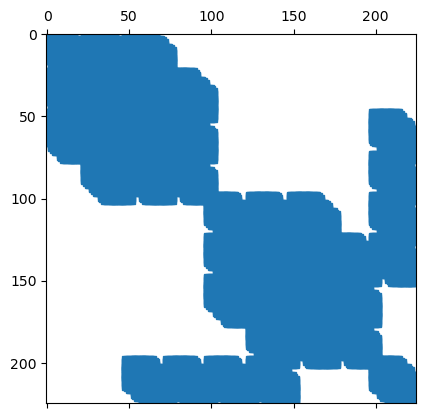

In [21]:
plt.spy(Kh)

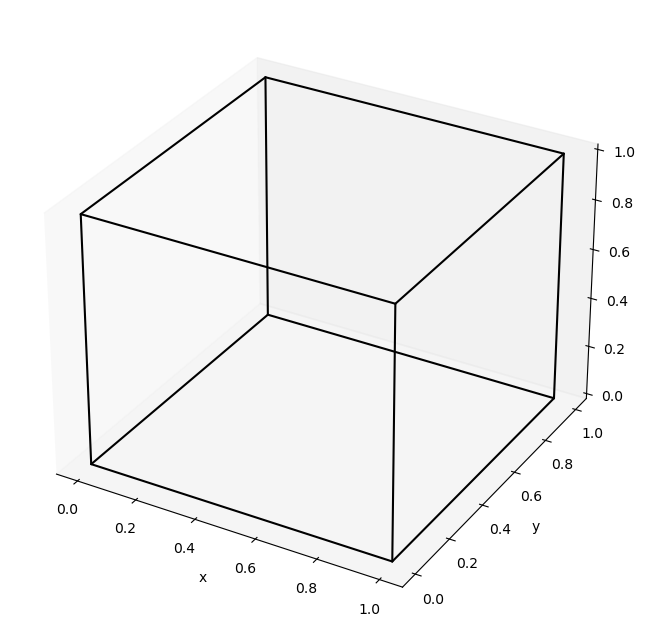

In [10]:
M.plotmesh(knots=0)

In [61]:
print(MB.B[-1,:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 54)>
  Coords	Values
  (0, 26)	-1.0
  (0, 35)	1.0


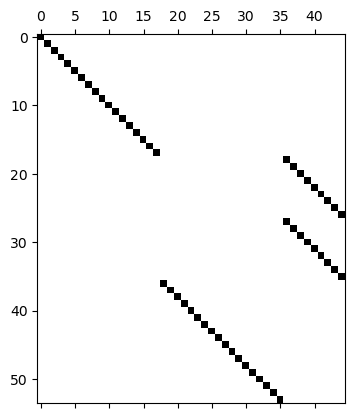

In [68]:
plt.spy(MB.Basis.toarray())

In [70]:
Kh.toarray()

array([[0.16667, 0.04167, 0.     , ..., 0.     , 0.     , 0.     ],
       [0.04167, 0.33333, 0.04167, ..., 0.     , 0.     , 0.     ],
       [0.     , 0.04167, 0.16667, ..., 0.     , 0.     , 0.     ],
       ...,
       [0.     , 0.     , 0.     , ..., 0.16667, 0.04167, 0.     ],
       [0.     , 0.     , 0.     , ..., 0.04167, 0.33333, 0.04167],
       [0.     , 0.     , 0.     , ..., 0.     , 0.04167, 0.16667]])

In [18]:
err = assemble.assemble(
    '(u-uh)**2 * v * dx',
    kvs=kvs,
    geo=geo,
    u=u,
    uh=bspline.BSplineFunc(kvs,u_exact),
).sum()

print(np.sqrt(err))

5.789917759587536e-17


In [73]:
assemble.boundary_dofs(kvs, ravel=True)

array([ 0,  1,  2,  3,  4,  5,  6,  7, 13, 14, 20, 21, 27, 28, 34, 35, 41, 42, 43, 44, 45, 46, 47, 48])

In [70]:
free = 
r = Kh[np.ix_(free, free)] @ u_exact[free] - Fh[free]
print(np.linalg.norm(r))

0.04800000000000007
[ 0  1  2  3  4  5  6  7 13 14 20 21 27 28 34 35 41 42 43 44 45 46 47 48]


In [34]:
L2err[1]/L2err[2]

0.9385534668465171

In [35]:
L2err[2]/L2err[3]

0.9787062339903757

In [36]:
H1err[0]/H1err[1]

0.7986894211317712

In [37]:
H1err[1]/H1err[2]

0.8987493808548614

In [38]:
H1err[2]/H1err[3]

0.9536482957994318

In [21]:
x,y,z = list(np.random.rand(3))
print("u_exact =", u(x,y,z))
print("u_h     =", uh(x,y,z))
print("diff    =", u(x,y,z)-uh(x,y,z))

u_exact = 1.138905599310453


TypeError: 'list' object is not callable

In [22]:
kvs= MB.mesh.kvs[0]

In [28]:
kvs[0].mesh

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [29]:
bspline.KnotVector()

TypeError: KnotVector.__init__() missing 2 required positional arguments: 'knots' and 'p'

In [30]:
tuple(bspline.KnotVector(kvs[i].mesh,0) for i in range(3))

(KnotVector(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), 0),
 KnotVector(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), 0),
 KnotVector(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), 0))

In [13]:
np.random.rand(3)

array([0.44526, 0.5266 , 0.31637])

In [20]:
f(*np.random.rand(3))

-6.0

In [9]:
MB.mesh.kvs[0][0]

KnotVector(array([0.  , 0.  , 0.  , 0.  , 0.25, 0.5 , 0.75, 1.  , 1.  , 1.  , 1.  ]), 3)

In [82]:
MB = assemble.MultiBasis(M, subspace='C0')

setting up constraints took 0.08449077606201172 seconds.
Basis setup took 0.015715837478637695 seconds


In [83]:
Mh = MB.assemble_volume('u * v *dx', arity=2)
Kh = MB.assemble_volume('inner(grad(u),grad(v))*dx', arity=2)
Fh = MB.assemble_volume('f * v * dx', arity=1, f=f)
Uh = MB.assemble_volume('f * v * dx', arity=1, f=u)
u_exact = operators.make_solver(Mh)@Uh

In [84]:
dir_bcs = MB.set_fixed_boundary({0:0})

In [85]:
LS = assemble.RestrictedLinearSystem(Kh,Fh,dir_bcs)

In [86]:
uh = LS.complete(operators.make_solver(LS.A, spd=True)@LS.b)

In [87]:
eh=uh-u_exact

In [89]:
np.sqrt(eh@Mh@eh)

np.float64(0.229048584915279)